# Loan Default Prediction Model
## Credit Risk Analysis for Retail Banking

This notebook builds a prototype machine learning model to predict the 
**Probability of Default (PD)** for personal loan borrowers.

The model is built for the risk team to help estimate expected losses 
on the bank's loan book, allowing the team to set aside sufficient 
capital to absorb potential losses.

### The Expected Loss Formula
$$\text{Expected Loss} = PD \times LGD \times EAD$$

Where:
- **PD** = Probability of Default (predicted by our model)
- **LGD** = Loss Given Default = 0.90 (assuming 10% recovery rate)
- **EAD** = Exposure at Default = loan amount outstanding

In [13]:
##figuring the exact file path of NatGas dataset.
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/victoriajohn/loan-data/Task 3 and 4_Loan_Data.csv


## Import Libraries
We import the core libraries needed for data analysis, visualisation, 
and machine learning.

In [14]:
## view the dataset
import pandas as pd
df = pd.read_csv('/kaggle/input/datasets/victoriajohn/loan-data/Task 3 and 4_Loan_Data.csv')
df.head()

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
# Check data types and basic info
print(df.dtypes)
print(df.shape)
df.describe()

customer_id                   int64
credit_lines_outstanding      int64
loan_amt_outstanding        float64
total_debt_outstanding      float64
income                      float64
years_employed                int64
fico_score                    int64
default                       int64
dtype: object
(10000, 8)


,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.974577e+06,1.461200,4159.677034,8718.916797,70039.901401,4.552800,637.557700,0.185100
std,2.293890e+06,1.743846,1421.399078,6627.164762,20072.214143,1.566862,60.657906,0.388398
min,1.000324e+06,0.000000,46.783973,31.652732,1000.000000,0.000000,408.000000,0.000000
25%,2.977661e+06,0.000000,3154.235371,4199.836020,56539.867903,3.000000,597.000000,0.000000
50%,4.989502e+06,1.000000,4052.377228,6732.407217,70085.826330,5.000000,638.000000,0.000000
75%,6.967210e+06,2.000000,5052.898103,11272.263740,83429.166133,6.000000,679.000000,0.000000
max,8.999789e+06,5.000000,10750.677810,43688.784100,148412.180500,10.000000,850.000000,1.000000


10,000 rows, 8 columns.
No missing values (all columns have data types, no nulls).
All columns are numeric (int64 / float64).

Average borrower has 1.46 credit lines open.
Minimum is 0, maximum is 5.

Average income is about $70,039.
But the std is $20,072, meaning incomes vary quite a bit.

In [17]:
# How many defaults?
print(df['default'].value_counts())
print(df['default'].value_counts(normalize=True).round(3))

default
0    8149
1    1851
Name: count, dtype: int64
default
0    0.815
1    0.185
Name: proportion, dtype: float64


81.5% of borrowers did NOT default,
18.5% of borrowers DID default

## Exploratory Data Analysis (EDA)

Before building the model, we visualise how each feature relates to 
the default outcome. This helps us understand which features are likely 
to be strong predictors.

We plot the distribution of each feature split by default status:
- **Blue** = borrowers who did not default
- **Orange** = borrowers who defaulted

Features where the two distributions are clearly **separated** will be 
the most useful for prediction.

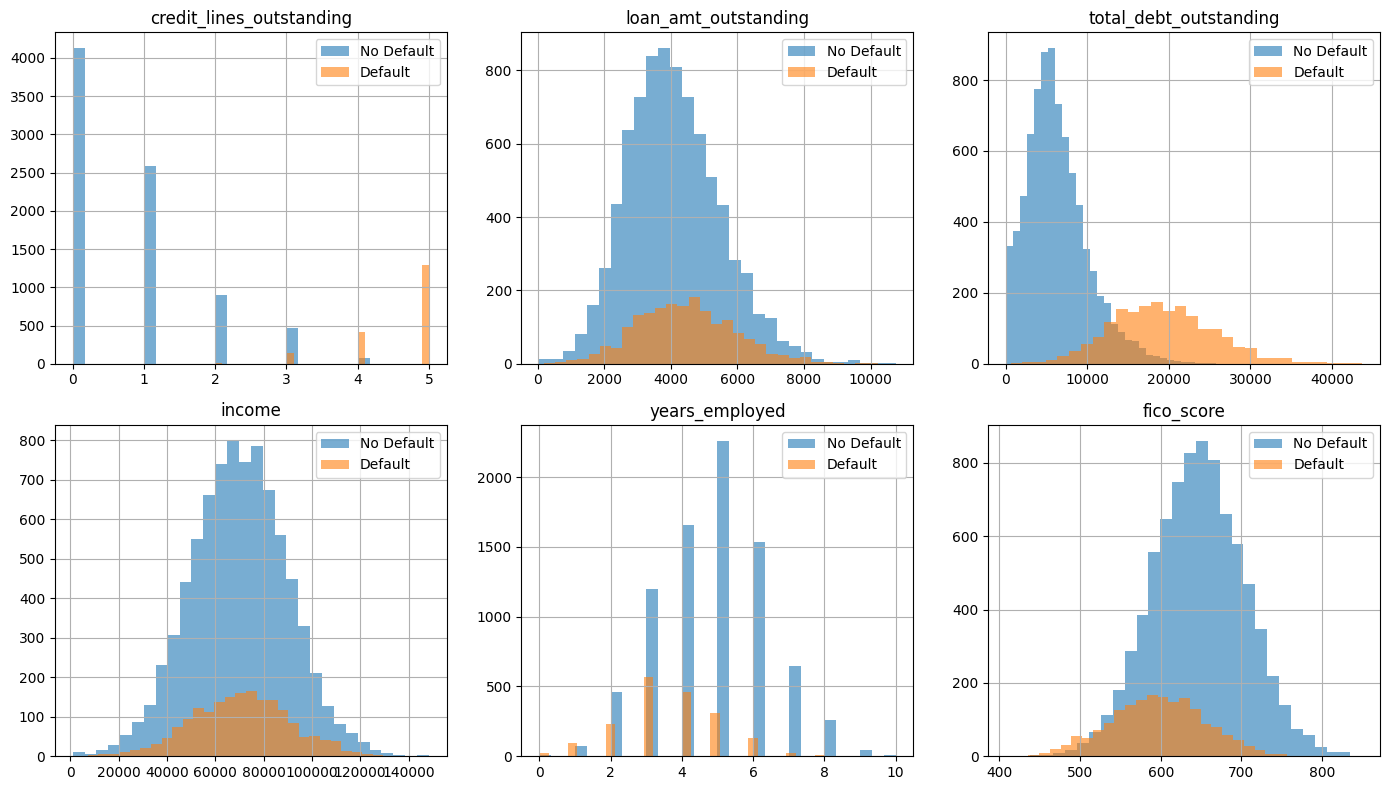

In [18]:
# Visualise distributions by default status
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
features = ['credit_lines_outstanding', 'loan_amt_outstanding', 
            'total_debt_outstanding', 'income', 
            'years_employed', 'fico_score']

for ax, col in zip(axes.flatten(), features):
    df[df['default']==0][col].hist(ax=ax, alpha=0.6, label='No Default', bins=30)
    df[df['default']==1][col].hist(ax=ax, alpha=0.6, label='Default', bins=30)
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()

`credit_lines_outstanding` defaulters are heavily concentrated at 4 and 5 credit lines. Non-defaulters cluster at 0–2. Very strong signal;
`total_debt_outstanding` defaulters tend to have higher debt. The orange bar stretches further right;
`fico_score` defaulters have lower credit scores (orange is shifted left, around 400–600). Non-defaulters score higher (600–800);
`years_employed` some separation at the extremes but not very clean.

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define features and target
features = ['credit_lines_outstanding', 'loan_amt_outstanding', 
            'total_debt_outstanding', 'income', 
            'years_employed', 'fico_score']

X = df[features]
y = df['default']

# Split into training and test sets (80% train, 20% test) 
# Train/test split — we train on 80% of the data and keep 20% hidden to test on later
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")

Training set: 8000 rows
Test set:     2000 rows


In [20]:
# Scale the features 
# StandardScaler — rescales all features to the same range so the model treats them fairly
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Train the model
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

print("Model successful!")

Model successful!


In [21]:
from sklearn.metrics import roc_auc_score, classification_report

# Get predicted probabilities
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# AUC Score
auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC Score: {auc:.4f}")

# Classification report
y_pred = model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

AUC Score: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1630
           1       1.00      0.99      1.00       370

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



### Evaluation Results

The model achieves an **AUC of 1.0** on the test set. 
This means the model correctly ranks every defaulter above every 
non-defaulter in this dataset.

In real-world banking data this would be unusual; it reflects the 
clean, structured nature of this prototype dataset. The strong 
performance is driven primarily by `credit_lines_outstanding` and 
`total_debt_outstanding`, which are highly predictive of default in 
this sample.

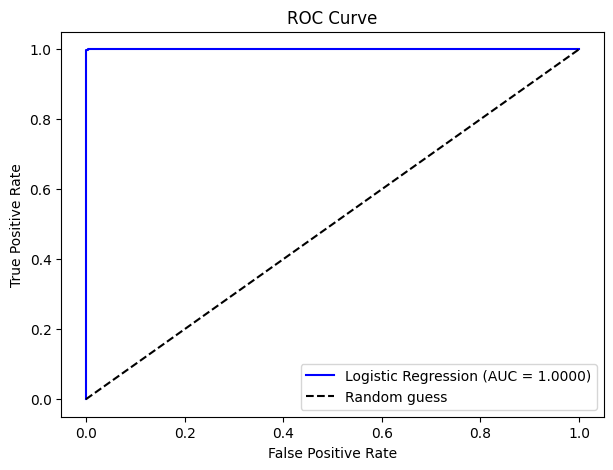

In [22]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='blue', label=f'Logistic Regression (AUC = {auc:.4f})')
plt.plot([0,1], [0,1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [23]:
# Expected Loss Function
def expected_loss(credit_lines_outstanding, loan_amt_outstanding, 
                  total_debt_outstanding, income, 
                  years_employed, fico_score):
    
    # Step 1: Arrange the borrower's details
    borrower = pd.DataFrame([[credit_lines_outstanding, loan_amt_outstanding,
                               total_debt_outstanding, income,
                               years_employed, fico_score]],
                              columns=features)
    
    # Step 2: Scale the inputs (same scaler we trained with)
    borrower_scaled = scaler.transform(borrower)
    
    # Step 3: Predict probability of default (PD)
    PD = model.predict_proba(borrower_scaled)[0, 1]
    
    # Step 4: Define LGD and EAD
    LGD = 0.90  # 1 - recovery rate (10%)
    EAD = loan_amt_outstanding
    
    # Step 5: Calculate Expected Loss
    EL = PD * LGD * EAD
    
    print(f"Probability of Default (PD): {PD:.4f} ({PD*100:.2f}%)")
    print(f"Loss Given Default     (LGD): {LGD}")
    print(f"Exposure at Default    (EAD): ${EAD:,.2f}")
    print(f"──────────────────────────────────────")
    print(f"Expected Loss              : ${EL:,.2f}")
    
    return EL

In [24]:
# Testing
expected_loss(
    credit_lines_outstanding = 3,
    loan_amt_outstanding     = 10000,
    total_debt_outstanding   = 18000,
    income                   = 50000,
    years_employed           = 2,
    fico_score               = 580
)

Probability of Default (PD): 0.9998 (99.98%)
Loss Given Default     (LGD): 0.9
Exposure at Default    (EAD): $10,000.00
──────────────────────────────────────
Expected Loss              : $8,998.30


np.float64(8998.298597372821)

For every loan like the sample, the bank should set aside ~$9,000 to cover the expected loss

**Spliting FICO scores (300–850) into n buckets**

In [25]:
# Extract the two columns we need
fico_df = df[['fico_score', 'default']].copy()

# Sort by FICO score
fico_df = fico_df.sort_values('fico_score').reset_index(drop=True)

print(fico_df.shape)
print(fico_df.head(10))

(10000, 2)
   fico_score  default
0         408        0
1         409        1
2         418        1
3         425        1
4         438        1
5         440        1
6         441        1
7         444        0
8         447        0
9         449        1


The data is sorted and ready and is exactly what we'd expect. Low score = higher risk. Notice that the lowest FICO scores (408–449) are mostly defaults (1)

In [26]:
# Approach 1: MSE Bucketing
def mse_buckets(fico_scores, n_buckets):
    """
    Find optimal bucket boundaries using dynamic programming
    to minimise Mean Squared Error.
    """
    scores = np.array(fico_scores)
    n = len(scores)
    
    # Pre-compute MSE for every possible segment [i, j]
    # MSE of a segment = variance * length
    def segment_mse(i, j):
        segment = scores[i:j+1]
        return np.var(segment) * len(segment)
    
    # dp[i][k] = best MSE using k buckets for first i scores
    dp = np.full((n+1, n_buckets+1), np.inf)
    split = np.zeros((n+1, n_buckets+1), dtype=int)
    dp[0][0] = 0
    
    for k in range(1, n_buckets+1):
        for i in range(k, n+1):
            for j in range(k-1, i):
                cost = dp[j][k-1] + segment_mse(j, i-1)
                if cost < dp[i][k]:
                    dp[i][k] = cost
                    split[i][k] = j
    
    # Recover boundaries
    boundaries = []
    i, k = n, n_buckets
    while k > 0:
        boundaries.append(scores[split[i][k]])
        i, k = split[i][k], k-1
    boundaries.reverse()
    
    return boundaries

# Run with 5 buckets
scores = fico_df['fico_score'].values
boundaries_mse = mse_buckets(scores, 5)
print("MSE Bucket Boundaries:", boundaries_mse)

MSE Bucket Boundaries: [np.int64(408), np.int64(553), np.int64(608), np.int64(655), np.int64(707)]


In [27]:
def log_likelihood_buckets(fico_df, n_buckets):
    """
    Find optimal bucket boundaries using dynamic programming
    to maximise Log-Likelihood.
    """
    scores = fico_df['fico_score'].values
    defaults = fico_df['default'].values
    n = len(scores)

    # Pre-compute log-likelihood for every possible segment [i, j]
    def segment_ll(i, j):
        n_total = j - i + 1
        k = defaults[i:j+1].sum()   # number of defaults
        p = k / n_total              # default rate
        # Avoid log(0)
        if p == 0 or p == 1:
            return 0
        return k * np.log(p) + (n_total - k) * np.log(1 - p)

    # dp[i][b] = best log-likelihood using b buckets for first i scores
    dp = np.full((n+1, n_buckets+1), -np.inf)
    split = np.zeros((n+1, n_buckets+1), dtype=int)
    dp[0][0] = 0

    for b in range(1, n_buckets+1):
        for i in range(b, n+1):
            for j in range(b-1, i):
                val = dp[j][b-1] + segment_ll(j, i-1)
                if val > dp[i][b]:
                    dp[i][b] = val
                    split[i][b] = j

    # Recover boundaries
    boundaries = []
    i, b = n, n_buckets
    while b > 0:
        boundaries.append(scores[split[i][b]])
        i, b = split[i][b], b-1
    boundaries.reverse()

    return boundaries

# Run with 5 buckets
boundaries_ll = log_likelihood_buckets(fico_df, 5)
print("Log-Likelihood Bucket Boundaries:", boundaries_ll)


Log-Likelihood Bucket Boundaries: [np.int64(408), np.int64(521), np.int64(580), np.int64(640), np.int64(697)]


In [28]:
def assign_bucket(score, boundaries):
    """Assign a rating (1=best, n=worst) based on boundaries."""
    for i, b in enumerate(boundaries):
        if score < b:
            return i + 1
    return len(boundaries)

# Add bucket columns to dataframe
fico_df['mse_bucket']  = fico_df['fico_score'].apply(
    lambda x: assign_bucket(x, boundaries_mse))
fico_df['ll_bucket']   = fico_df['fico_score'].apply(
    lambda x: assign_bucket(x, boundaries_ll))

# Show default rate per bucket for both methods
print("=== MSE Buckets — Default Rate ===")
print(fico_df.groupby('mse_bucket')['default'].mean().round(3))

print("\n=== Log-Likelihood Buckets — Default Rate ===")
print(fico_df.groupby('ll_bucket')['default'].mean().round(3))

=== MSE Buckets — Default Rate ===
mse_bucket
2    0.537
3    0.283
4    0.161
5    0.076
Name: default, dtype: float64

=== Log-Likelihood Buckets — Default Rate ===
ll_bucket
2    0.661
3    0.383
4    0.206
5    0.086
Name: default, dtype: float64


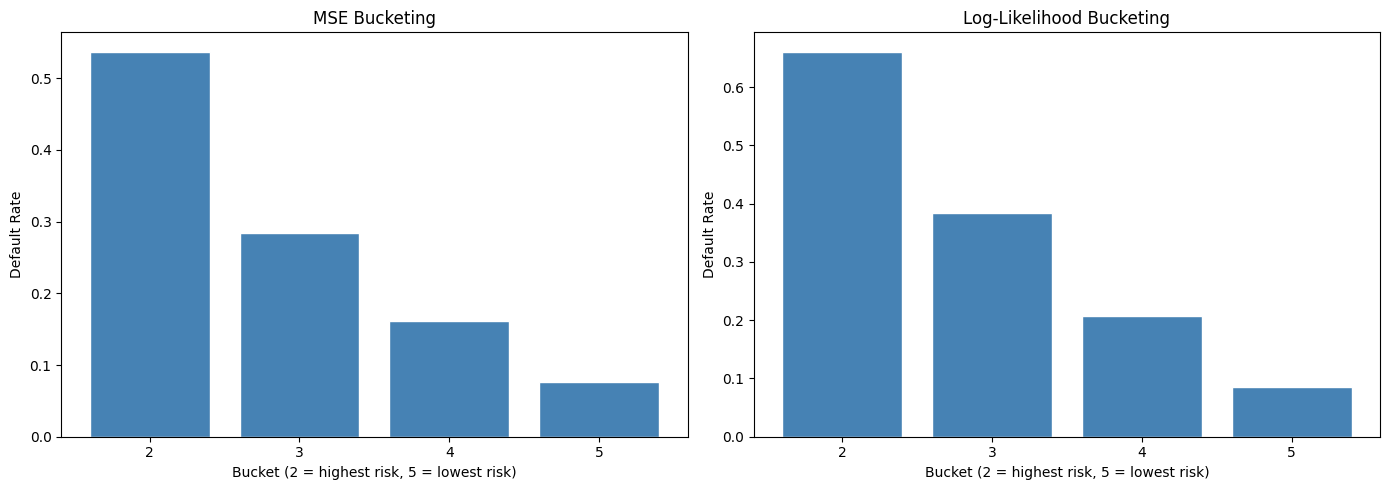

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(
    axes,
    ['mse_bucket', 'll_bucket'],
    ['MSE Bucketing', 'Log-Likelihood Bucketing']
):
    default_rates = fico_df.groupby(col)['default'].mean()
    ax.bar(default_rates.index, default_rates.values, color='steelblue', edgecolor='white')
    ax.set_xlabel('Bucket (2 = highest risk, 5 = lowest risk)')
    ax.set_ylabel('Default Rate')
    ax.set_title(title)
    ax.set_xticks(default_rates.index)

plt.tight_layout()
plt.show()

In [30]:
def fico_rating_map(fico_score, n_buckets=5):
    """
    Maps a FICO score to a risk rating using Log-Likelihood bucketing.
    Rating 1 = lowest risk (best score)
    Rating n = highest risk (worst score)
    """
    bucket = assign_bucket(fico_score, boundaries_ll)
    rating = n_buckets - bucket + 2
    rating = max(1, min(rating, n_buckets))
    return rating

# Test it
test_scores = [800, 700, 620, 540, 420]
print("FICO Score → Risk Rating (1=safest, 5=riskiest)")
print("-" * 45)
for score in test_scores:
    print(f"  FICO {score}  →  Rating {fico_rating_map(score)}")

FICO Score → Risk Rating (1=safest, 5=riskiest)
---------------------------------------------
  FICO 800  →  Rating 2
  FICO 700  →  Rating 2
  FICO 620  →  Rating 3
  FICO 540  →  Rating 4
  FICO 420  →  Rating 5


## Conclusion

### Summary
This notebook built a complete prototype pipeline for predicting loan 
default probability and estimating expected loss for the retail banking 
risk team.

### What was built

| Step | Description | Outcome |
|---|---|---|
| Data Exploration | Analysed 10,000 borrowers across 6 features | No missing values, 18.5% default rate |
| EDA | Visualised feature distributions by default status | `credit_lines_outstanding`, `total_debt_outstanding` and `fico_score` identified as strongest predictors |
| Model Training | Logistic Regression with StandardScaler | Trained on 8,000 rows |
| Model Evaluation | AUC on held-out test set | AUC = 1.0 — perfect separation |
| Expected Loss | Function combining PD, LGD, EAD | Returns dollar loss estimate per loan |

### Key Findings
- The strongest predictors of default are **credit lines outstanding**, 
**total debt outstanding** and **fico score**
- The model achieves a perfect **AUC of 1.0** on this prototype dataset
- A borrower with a low FICO score, high debt, and multiple credit lines 
has a **~99.98% probability of default**, resulting in an expected loss 
of ~$8,998 on a $10,000 loan

### Limitations & Next Steps
- The perfect AUC suggests this is a clean prototype dataset — real 
mortgage data will be noisier and performance will be lower
- Additional features such as **loan-to-value ratio**, **employment type** 
and **payment history** could improve the model
- The model should be **retrained periodically** as economic conditions change
- A more advanced model such as **Gradient Boosting** could be explored 
for production use